In [25]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors

import scanpy as sc

import os

import scvi

import seaborn as sns


def order_m(m):
    n = min(*m.shape)
    
    ordered_cols = []
    remain_cols = list(range(m.shape[1]))
    
    for i in range(n):
        ic = m[i, remain_cols].argmax()
        c = remain_cols[ic]
        ordered_cols.append(c)
        remain_cols.remove(c)
    
    return ordered_cols, remain_cols

# Some canonical markers for PBMC cell types that I found
canonical_markers = ["IL32", "LTB", "CD3D",
    "IL7R", "LDHB", "FCGR3A", 
    "CD68", "MS4A1", "GNLY", 
    "CD3E", "CD14", "CD14", 
    "FCGR3A", "LYZ", "PPBP", 
    "CD8A", "PPBP", "CST3", 
    "NKG7", "MS4A7", "MS4A1", 
    "CD8A", "CD4", "NCAM1"]

    

In [2]:
## Downloaded CR-arc count matrix results
data_dir = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/downloaded_counts/VIB_10xmultiome_2'

h5_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2-outs-raw_feature_bc_matrix-matrix.h5ad')

barcodes_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.barcodes.tsv')

features_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.features.tsv')

h5 = sc.read_h5ad(h5_file)

features_pd = pd.read_csv(features_file, header=None, sep='\t')

barcodes_pd = pd.read_csv(barcodes_file, header=None, sep='\t')

## It's feature -by- barcode matrix, need to transpose
h5.var = barcodes_pd
h5.obs = features_pd 
h5.obs.columns = ['feature_id', 'name', 'feature_type', 'chrom', 'start', 'end']
h5.var.columns = ['barcodes']


## Entropy filtered atac
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
entropy_downstream_dir = os.path.join(entropy_dir, 'DownstreamReanalysis')
entropy_peak_file = os.path.join(entropy_downstream_dir, 'entropy_peakvi.h5ad')
peak_file = os.path.join(entropy_downstream_dir, 'peakvi.h5ad')

entropy_peak = sc.read_h5ad(entropy_peak_file)
peak = sc.read_h5ad(peak_file)

# Rename peakvi clustering columns
entropy_peak.obs['clusters_peakvi_entropy'] = entropy_peak.obs['clusters_peakvi']
peak.obs['clusters_peakvi_standard'] = peak.obs['clusters_peakvi']

# Load entropy score and add to entropy_peak obs
entropy_score_file = os.path.join(entropy_dir, 'entropy_filtered_bc_df.tsv')
entropy_score_pd = pd.read_csv(entropy_score_file, sep=',', index_col=0)
entropy_peak.obs = entropy_peak.obs.merge(entropy_score_pd[['Entropy', 'Entropy_open_region']], left_on='barcodes', right_index=True, how='left')



# atac-rna-barcode map 
bc_map_file = '/home/syyang/adipose_ln/multiom/atac_rna_barcodes_map.tsv'
bc_map_pd = pd.read_csv(bc_map_file, sep='\t')



## load peakvi models for DARS analysis 
standard_peak_model_dir = os.path.join(entropy_downstream_dir, 'standard_peak_peakvi_model')
entropy_peak_model_dir =os.path.join(entropy_downstream_dir, 'entropy_peak_peakvi_model')
standard_peak_model =scvi.model.PEAKVI.load(standard_peak_model_dir, adata=peak)
entropy_peak_model =scvi.model.PEAKVI.load(entropy_peak_model_dir, adata=entropy_peak)


# Summary statistics about Fraction of Reads in Peaks (FRIP)
standard_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_peaks.csv')
entropy_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_entropypeaks.csv')


standard_peak_frip = pd.read_csv(standard_peak_frip_file, index_col=None, sep='\t')
entropy_peak_frip = pd.read_csv(entropy_peak_frip_file, index_col=None, sep='\t')
standard_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip['atac_bc'] = entropy_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip['atac_bc'] = standard_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip.set_index('atac_bc', inplace=True)
entropy_peak_frip.set_index('atac_bc', inplace=True)

INFO     File                                                                                                      
         /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/DownstreamReanalysis/standard_peak_peakvi_mode
         l/model.pt already downloaded                                                                             
INFO     File                                                                                                      
         /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/DownstreamReanalysis/entropy_peak_peakvi_model
         /model.pt already downloaded                                                                              


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_

In [3]:
entropy_peak, peak, h5, features_pd.shape, barcodes_pd.shape, bc_map_pd.shape

(AnnData object with n_obs × n_vars = 2125 × 36729
     obs: 'barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi', 'clusters_peakvi_entropy', 'Entropy', 'Entropy_open_region'
     var: 'peak'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'clusters_peakvi', 'neighbors', 'umap'
     obsm: 'X_peakvi', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 2125 × 31116
     obs: 'barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi', 'clusters_peakvi_standard'
     var: 'peak'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'clusters_peakvi', 'neighbors', 'umap'
     obsm: 'X_peakvi', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 104068 × 687495
     obs: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end'
     var: 'barcodes',
 (104068, 6),
 (687495, 1),
 (736320, 2))

# Plot on atac space 

In [4]:
# atac clsutering at different resolutions (than previously used)
atac_resolution = 0.5
sc.tl.leiden(entropy_peak, key_added='clusters_peakvi_highres_entropy', resolution=atac_resolution)
sc.tl.leiden(peak, key_added='clusters_peakvi_highres_standard', resolution=atac_resolution)

/tmp/ipykernel_2495697/2040503211.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(entropy_peak, key_added='clusters_peakvi_highres_entropy', resolution=atac_resolution)


## Matching atac bc with RNA bc

In [5]:
bc_map = bc_map_pd.set_index('atac_barcodes')

entropy_peak.obs['atac_bc'] =  entropy_peak.obs['barcodes'].map(lambda x: x.split('-1')[0])
entropy_peak.obs.set_index('atac_bc', inplace=True)
if 'rna_barcodes' not in entropy_peak.obs.columns:
    entropy_peak.obs = entropy_peak.obs.join(bc_map, how='inner')


peak.obs['atac_bc'] =  peak.obs['barcodes'].map(lambda x: x.split('-1')[0])
peak.obs.set_index('atac_bc', inplace=True)
if 'rna_barcodes' not in peak.obs.columns:
    peak.obs = peak.obs.join(bc_map, how='inner')


bc_passed_entropy_df = entropy_peak.obs[['rna_barcodes']]

# RNA clustering

In [6]:
# prepare for rna-bc correspondence to atac entropy filtered barcodes
entropy_passed_bc_map=bc_passed_entropy_df.reset_index(inplace=False)
entropy_passed_bc_map.set_index('rna_barcodes', inplace=True)
entropy_passed_bc_map.columns = ['atac_bc']


h5_rna_ = h5.transpose()
h5_rna_.obs['rna_barcodes'] = h5_rna_.obs['barcodes'].map(lambda x: x.split('-1')[0])
h5_rna_.obs.set_index('rna_barcodes', inplace=True)


# select gene expression only, and only the barcodes that passed entropy filtering
h5_rna_ = h5_rna_[:, h5_rna_.var['feature_type'] == 'Gene Expression']
h5_rna_ = h5_rna_[h5_rna_.obs.index.isin(entropy_passed_bc_map.index), :]
h5_rna_.obs = h5_rna_.obs.join(entropy_passed_bc_map, how='inner')

# calculate total RNA QC metrics
h5_rna_.obs['total_RNA_UMI'] = h5_rna_.X.sum(axis=1)
h5_rna_.obs['total_RNA_UMI_log'] = np.log1p(h5_rna_.obs['total_RNA_UMI'])
h5_rna_.obs['n_genes_by_RNA_counts'] = (h5_rna_.X > 0).sum(axis=1)
h5_rna_.obs['N_MT_counts'] = h5_rna_.X[:, h5_rna_.var.name.apply(lambda x: x.startswith('MT-'))].sum(axis=1)
h5_rna_.obs['MT%'] = h5_rna_.obs['N_MT_counts'] / h5_rna_.obs['total_RNA_UMI'] * 100

X_10k = sc.pp.normalize_total(h5_rna_, target_sum=1e4, inplace=False)['X']
h5_rna_.layers['log1p_counts'] = np.log1p(X_10k.copy())

h5_rna = h5_rna_[:, ~h5_rna_.var.name.apply(lambda x: x.startswith('MT-'))].copy() # Remove MT genes

# Add gene_name column 
h5_rna.var['gene_name'] = h5_rna.var['name'].astype(str)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


In [7]:
h5_rna, h5_rna_.shape

(AnnData object with n_obs × n_vars = 2125 × 36588
     obs: 'barcodes', 'atac_bc', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end', 'gene_name'
     layers: 'log1p_counts',
 (2125, 36601))

In [8]:
sc.pp.filter_genes(h5_rna, min_counts=3)
h5_rna.raw = h5_rna # keep full dimension safe
h5_rna.layers['counts'] = h5_rna.X
sc.pp.highly_variable_genes(
h5_rna,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

In [9]:
# scvi.settings.seed = 0
# scvi.model.SCVI.setup_anndata(h5_rna, layer="counts")
# vae = scvi.model.SCVI(h5_rna, n_layers=3, n_latent=30, gene_likelihood="nb")
# vae.train()
# h5_rna.obsm["RNA_scVI"] = vae.get_latent_representation()

# sc.pp.neighbors(h5_rna, use_rep='RNA_scVI')
# sc.tl.umap(h5_rna, min_dist=0.3)

# print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
# vae_model_folder=os.path.join(entropy_dir, "RNA_scvi_model")
# vae.save(vae_model_folder)
vae_model_folder=os.path.join(entropy_dir, "RNA_scvi_model")
vae =scvi.model.SCVI.load(vae_model_folder, adata=h5_rna)
h5_rna.obsm["RNA_scVI"] = vae.get_latent_representation()
sc.pp.neighbors(h5_rna, use_rep='RNA_scVI')
sc.tl.umap(h5_rna, min_dist=0.3)


INFO     File /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/RNA_scvi_model/model.pt already          
         downloaded                                                                                                


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_

In [10]:
# clustering using scVI latent representation via Leiden
sc.tl.leiden(h5_rna, key_added="leiden_RNA_scVI", resolution=atac_resolution + 0.1)

## Cell-type annotation from Julianaa

### Provicve clsuter to cell-type map

In [11]:
# Juliana's cell type annotation
RNAcluster_celltype_map = {
'0': 'CD14+ Mo',
'1': 'CD4+CD8+ naive T cells',
'2': 'Tregs',
'3': 'B cells',
'4': 'ILC/NK cells',
'5': 'MAIT/NK T cells',
'6': 'gammaSignma T cells',
'7': 'Unknown',
'8': 'CD16+Mo',
'9': 'pDCs',
'10': 'Plasma cells (noisy)'
}
h5_rna.obs['celltype'] = h5_rna.obs['leiden_RNA_scVI'].map(RNAcluster_celltype_map)

### plot to see cell-type fraction of reads in peaks (FRIP) for standard peak set and entropy peak set

In [12]:
if 'standard_peak_FRIP' in h5_rna.obs.columns:
    h5_rna.obs.drop(columns=['standard_peak_FRIP'], inplace=True)
if 'entropy_peak_FRIP' in h5_rna.obs.columns:
    h5_rna.obs.drop(columns=['entropy_peak_FRIP'], inplace=True)
    
h5_rna.obs = h5_rna.obs.merge(standard_peak_frip[['frag_overlap_peaks%']].rename(columns={'frag_overlap_peaks%': 'standard_peak_FRIP'}),\
    left_on='atac_bc', right_index=True, how='left')

h5_rna.obs = h5_rna.obs.merge(entropy_peak_frip[['frag_overlap_entropy_peaks%']].rename(columns={'frag_overlap_entropy_peaks%': 'entropy_peak_FRIP'}),\
    left_on='atac_bc', right_index=True, how='left')

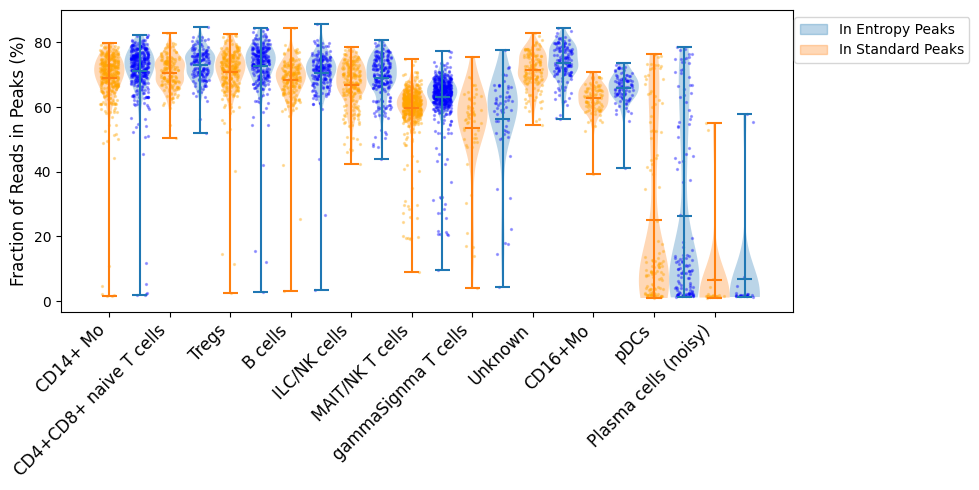

In [13]:
# color_maps = {'0': 'blue', '1': 'orange', '2': 'green', '3': 'red', '4': 'purple',
#               '5': 'brown', '6': 'pink', '7': 'gray', '8': 'olive', '9': 'cyan', '10': 'magenta'}
x_positions = range(11)
widths=0.5
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(10, 5))

# Violin plots
standard_peak_data = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == c, 'standard_peak_FRIP'] for c in h5_rna.obs['leiden_RNA_scVI'].unique()]
entropy_peak_data = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == c, 'entropy_peak_FRIP'] for c in h5_rna.obs['leiden_RNA_scVI'].unique()]

add_label(ax.violinplot( entropy_peak_data, 
              positions=[x + widths for x in x_positions], widths=widths, vert=True, 
              showmeans=True,), 'In Entropy Peaks')
add_label(ax.violinplot( standard_peak_data, 
              positions=x_positions, widths=widths, vert=True, 
              showmeans=True), 'In Standard Peaks')

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.15, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size

for i, group_data in enumerate(standard_peak_data):
    add_jittered_points(ax, group_data, x_positions[i], color='orange')
for i, group_data in enumerate(entropy_peak_data):
    add_jittered_points(ax, group_data, [x + widths for x in x_positions][i], color='blue')



ax.set_xticks(x_positions)
ax.set_xticklabels([RNAcluster_celltype_map[str(c)] for c in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
plt.legend(*zip(*labels), loc='upper right', bbox_to_anchor=(1.25, 1), ncol=1)

plt.tight_layout()


# Compare Cell-calling approaches

## Load RNA cell Barcodes from RNA-only modality CR analysis

In [14]:
# Load Cell Ranger  RNA filtering criteria barcodes
CR_rnamodality_BC_file = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/rna/VIB_10xmultiome_2_rna/outs/filtered_feature_bc_matrix/barcodes.tsv'
CR_rnamodality_bc = pd.read_csv(CR_rnamodality_BC_file, header=None, sep='\t', names=['barcodes'])

# Load Cell Ranger ATAC filtering criteria barcodes
CR_atacmodality_BC_file ='/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/atac/VIB_10xmultiome_2/outs/filtered_peak_bc_matrix/barcodes.tsv'
CR_atacmodality_bc = pd.read_csv(CR_atacmodality_BC_file, header=None, sep='\t', names=['barcodes'])

CR_rnamodality_bc['rna_bc'] = CR_rnamodality_bc['barcodes'].map(lambda x: x.split('-1')[0])
CR_atacmodality_bc['atac_bc'] = CR_atacmodality_bc['barcodes'].map(lambda x: x.split('-1')[0])


# Load Entropy value for each barcode on atac 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
entropy_df_file = os.path.join(entropy_dir, 'chr1_barcode_entropy_df.tsv')
entropy_df = pd.read_csv(entropy_df_file, sep=',', index_col=0)
entropy_df['log10_Entropy'] = np.log10(entropy_df['Entropy'])
entropy_df['atac_bc'] = entropy_df.index.map(lambda x: x.split('-1')[0])

# Load Entropy filtered atac barcodes
# Use entropy_peak.obs or peak.obs # TODO: Change to be entropy_passed barcodes file 

# Load  atac-rna-barcode map 
bc_map_file = '/home/syyang/adipose_ln/multiom/atac_rna_barcodes_map.tsv'
bc_map_pd = pd.read_csv(bc_map_file, sep='\t')

# Summary statistics about Fraction of Reads in Peaks (FRIP)
standard_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_peaks.csv')
entropy_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_entropypeaks.csv')


standard_peak_frip = pd.read_csv(standard_peak_frip_file, index_col=None, sep='\t')
entropy_peak_frip = pd.read_csv(entropy_peak_frip_file, index_col=None, sep='\t')
standard_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip['atac_bc'] = entropy_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip['atac_bc'] = standard_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip.set_index('atac_bc', inplace=True)
entropy_peak_frip.set_index('atac_bc', inplace=True)


# Load peak annotations [including peak AUC score from Genrich peaks]
annotation_dir = os.path.join(entropy_dir, 'annotation')
peaks_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_peaks.bed'),      sep='\t')
entropy_peak_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_entropy_peaks.bed'), sep='\t')
lost_peaks_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_lost_peaks.bed'), sep='\t')
newly_discovered_peaks_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_newly_discovered_peaks.bed'),  sep='\t')

In [15]:
if 'standard_peak_FRIP' in entropy_df.columns:
    entropy_df.drop(columns=['standard_peak_FRIP'], inplace=True)
if 'entropy_peak_FRIP' in entropy_df.columns:
    entropy_df.drop(columns=['entropy_peak_FRIP'], inplace=True)
if 'total_fragments' in entropy_df.columns:
    entropy_df.drop(columns=['total_fragments'], inplace=True)
if 'Nfrag_overlap_standard_peak' in entropy_df.columns:
    entropy_df.drop(columns=['Nfrag_overlap_standard_peak'], inplace=True)
if 'Nfrag_overlap_entropy_peak' in entropy_df.columns:
    entropy_df.drop(columns=['Nfrag_overlap_entropy_peak'], inplace=True)

entropy_df = entropy_df.merge(standard_peak_frip[['frag_overlap_peaks%', 'total_fragments', 'frag_overlap_peaks']].rename(
    columns={'frag_overlap_peaks%': 'standard_peak_FRIP', 'frag_overlap_peaks': 'Nfrag_overlap_standard_peak'}),\
    left_on='atac_bc', right_index=True, how='left')
entropy_df = entropy_df.merge(entropy_peak_frip[['frag_overlap_entropy_peaks%', 'frag_overlap_entropy_peaks']].rename(
    columns={'frag_overlap_entropy_peaks%': 'entropy_peak_FRIP', 'frag_overlap_entropy_peaks': 'Nfrag_overlap_entropy_peak'}),\
    left_on='atac_bc', right_index=True, how='left')


entropy_df['total_fragment_log1p'] = np.log1p(entropy_df['total_fragments'])

## Map RNA and ATAC barcodes

In [16]:
bc_map = bc_map_pd.set_index('atac_barcodes')

if entropy_df.index.name != 'atac_barcodes':
    entropy_df.set_index('atac_bc', inplace=True)
    entropy_df.index.name = 'atac_barcodes'
    entropy_df['atac_bc'] = entropy_df.index.values
    
if 'rna_barcodes' not in entropy_df.columns:
    entropy_df = entropy_df.join(bc_map, how='inner')
    

entropy_df.shape

(33287, 15)

In [17]:
entropy_df.head()

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,log10_Entropy,standard_peak_FRIP,total_fragments,Nfrag_overlap_standard_peak,entropy_peak_FRIP,Nfrag_overlap_entropy_peak,total_fragment_log1p,atac_bc,rna_barcodes
atac_barcodes,,,,,,,,,,,,,,,
AAGCCATAGCTAATAG,0.005725,1.069145,11,0.343957,0.708959,0.999545,-2.242193,3.930818,636,25.0,4.559748,29.0,6.456770,AAGCCATAGCTAATAG,TCCGCCATCCAAGTTA
CACGGTAAGAATCACA,0.004039,1.910865,19,1.377521,0.252203,0.999694,-2.393755,3.393214,501,17.0,3.992016,20.0,6.218600,CACGGTAAGAATCACA,AGTTATGTCTTGGACG
ACTGGCTTCTAACTGT,0.013996,2.526995,94,2.283363,0.101941,0.998739,-1.853984,5.901288,932,55.0,6.330472,59.0,6.838405,ACTGGCTTCTAACTGT,TCACCTCAGCACCACA
TCAGGCTTCTTTGGTG,0.004926,1.123864,10,0.376438,0.686302,0.999616,-2.307501,4.285714,140,6.0,4.285714,6.0,4.948760,TCAGGCTTCTTTGGTG,CGCTATGAGTCAATTG
GGTTTACGTCACAGGG,0.007795,2.188419,43,1.624756,0.196960,0.999355,-2.108172,3.285421,487,16.0,3.285421,16.0,6.190315,GGTTTACGTCACAGGG,TGTGGCTCATGAGTTT


## Plot results

In [18]:
entropy_df['rna_pass_CR'] = entropy_df['rna_barcodes'].isin(CR_rnamodality_bc['rna_bc'])
entropy_df['atac_pass_CR'] = entropy_df['atac_bc'].isin(CR_atacmodality_bc['atac_bc'])
entropy_df['atac_pass_entropy'] = entropy_df['atac_bc'].isin(entropy_peak.obs.index)

In [19]:
entropy_df['identified_by_atac'] = entropy_df.apply(
    lambda row: 'both' if row['atac_pass_entropy'] and row['atac_pass_CR'] else 
                ('entropy_only' if row['atac_pass_entropy'] and not row['atac_pass_CR'] else 
                 ('cr_only' if not row['atac_pass_entropy'] and row['atac_pass_CR'] else 'none')), axis=1
)

In [20]:
entropy_df['identified_by_atac'].value_counts()

identified_by_atac
none            31103
both             1887
entropy_only      238
cr_only            59
Name: count, dtype: int64

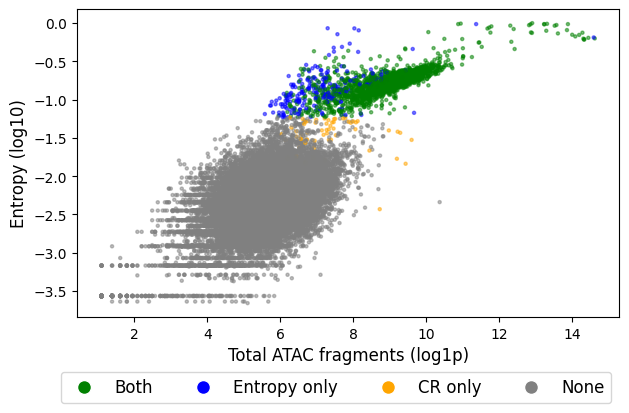

In [21]:


fig, ax = plt.subplots( figsize=(7, 4) )
colors = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
ax.scatter( entropy_df['total_fragment_log1p'], np.log10(entropy_df['Entropy']),  c= entropy_df['identified_by_atac'].map(colors), alpha=0.5, s=5, 
           )
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors.items()]
ax.legend(title='color', handles=handles, bbox_to_anchor=(0.75, 0.5), loc='upper left')
ax.set_xlabel('Total ATAC fragments (log1p)', fontsize=12)
ax.set_ylabel('Entropy (log10)', fontsize=12)




ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label='Both',
                          markerfacecolor='green', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Entropy only',
                           markerfacecolor='blue', markersize=10), 
                 Line2D([0], [0], marker='o', color='w', label='CR only',
                           markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='None',
                           markerfacecolor='gray', markersize=10)],
             bbox_to_anchor=(1, -0.15), loc='upper right', ncol=4, fontsize=12)

# cax_0 = ax.inset_axes([1.1, 0, 0.03, 1], transform=ax.transAxes)
# fig.colorbar(ax.collections, ax=ax, cax=cax_0, label='Fragments% overlapping called peaks')

plt.show()

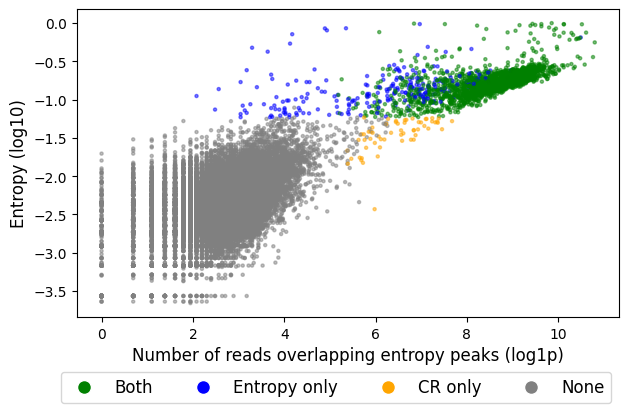

In [22]:


fig, ax = plt.subplots( figsize=(7, 4) )
colors = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
ax.scatter( np.log1p(entropy_df['Nfrag_overlap_entropy_peak']), np.log10(entropy_df['Entropy']),  c= entropy_df['identified_by_atac'].map(colors), alpha=0.5, s=5, 
           )
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors.items()]
ax.legend(title='color', handles=handles, bbox_to_anchor=(0.75, 0.5), loc='upper left')
ax.set_xlabel('Number of reads overlapping entropy peaks (log1p)', fontsize=12)
ax.set_ylabel('Entropy (log10)', fontsize=12)




ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label='Both',
                          markerfacecolor='green', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Entropy only',
                           markerfacecolor='blue', markersize=10), 
                 Line2D([0], [0], marker='o', color='w', label='CR only',
                           markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='None',
                           markerfacecolor='gray', markersize=10)],
             bbox_to_anchor=(1, -0.15), loc='upper right', ncol=4, fontsize=12)

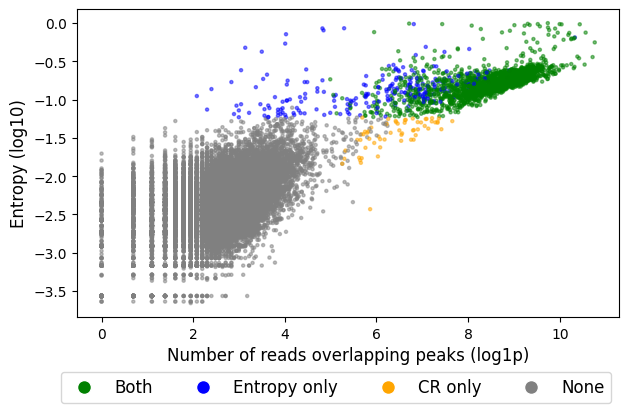

In [24]:
fig, ax = plt.subplots( figsize=(7, 4) )
colors = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
ax.scatter( np.log1p(entropy_df['Nfrag_overlap_standard_peak']), np.log10(entropy_df['Entropy']),  c= entropy_df['identified_by_atac'].map(colors), alpha=0.5, s=5, 
           )
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors.items()]
ax.legend(title='color', handles=handles, bbox_to_anchor=(0.75, 0.5), loc='upper left')
ax.set_xlabel('Number of reads overlapping peaks (log1p)', fontsize=12)
ax.set_ylabel('Entropy (log10)', fontsize=12)




ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label='Both',
                          markerfacecolor='green', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Entropy only',
                           markerfacecolor='blue', markersize=10), 
                 Line2D([0], [0], marker='o', color='w', label='CR only',
                           markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='None',
                           markerfacecolor='gray', markersize=10)],
             bbox_to_anchor=(1, -0.15), loc='upper right', ncol=4, fontsize=12)

Text(0, 0.5, 'Number of Reads in Peaks')

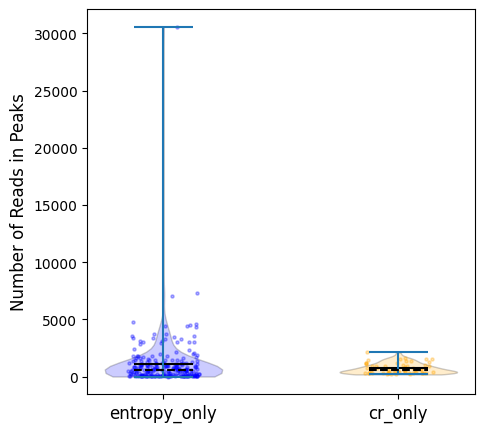

In [84]:
colors = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
gps = [ 'entropy_only', 'cr_only',]
x_positions = range(len(gps))
widths=0.5
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(5, 5))

# Violin plots

standard_peak_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'Nfrag_overlap_standard_peak'] for c in gps]
# entropy_peak_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'Nfrag_overlap_entropy_peak'] for c in gps]


# add_label(ax.violinplot( entropy_peak_data, 
#               positions=[x + widths for x in x_positions], widths=widths, vert=True, 
#               showmeans=True,), 'In Entropy Peaks')
vp1 = ax.violinplot( standard_peak_data, 
              positions=x_positions, widths=widths, vert=True, showmedians=True,
              showmeans=True)
add_label(vp1, 'In Standard Peaks')

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.15, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=5) # s controls point size

for i, group_data in enumerate(standard_peak_data):
    add_jittered_points(ax, group_data, x_positions[i], color='orange' if gps[i]=='cr_only' else 'blue')


for i, body in enumerate(vp1['bodies']):
    body.set_facecolor('blue' if gps[i]=='entropy_only' else 'orange')
    body.set_edgecolor('black')
    body.set_alpha(0.2)
vp1['cmedians'].set_color('black') 
vp1['cmedians'].set_linestyles('--')
vp1['cmeans'].set_color('black') 


ax.set_xticks(x_positions)
ax.set_xticklabels(gps, rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Number of Reads in Peaks', fontsize=12)

FRIP 	 entropy_only 	 cr_only 

Median 	 63.07 	 56.79 



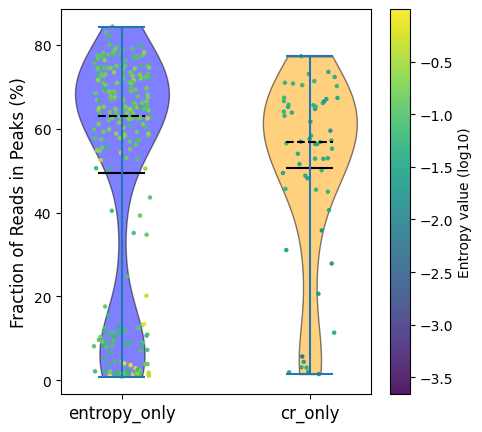

In [26]:
colors_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
gps = [ 'entropy_only', 'cr_only',]
x_positions = range(len(gps))
widths=0.5
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(5, 5))

# Violin plots

standard_peak_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'standard_peak_FRIP'] for c in gps]
entropy_values = [np.log10(entropy_df.loc[entropy_df['identified_by_atac'] == c, 'Entropy']) for c in gps]
color_range = (np.log10(entropy_df['Entropy'].min()), np.log10(entropy_df['Entropy'].max()))



vp1 = ax.violinplot( standard_peak_data, 
              positions=x_positions, widths=widths, vert=True, showmedians=True,
              showmeans=True)
add_label(vp1, 'In Standard Peaks')

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, poi_adj, jitter_width, color, color_range):
    # Generate random horizontal jitter
    x_jittered = position + poi_adj+ np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    norm = colors.Normalize(vmin=color_range[0], vmax=color_range[1])
    color_bar = ax.scatter(x_jittered, data_group, c=color, alpha=0.9, s=5, norm=norm) # s controls point size
    return color_bar



for i, group_data in enumerate(standard_peak_data):
    cb = add_jittered_points(ax, group_data, x_positions[i], 0,   color=entropy_values[i],color_range=color_range, jitter_width=0.15)

colorbar = fig.colorbar(cb, ax=ax, label='Entropy value (log10)')


for i, body in enumerate(vp1['bodies']):
    body.set_facecolor('blue' if gps[i]=='entropy_only' else 'orange')
    body.set_edgecolor('black')
    body.set_alpha(0.5)
vp1['cmedians'].set_color('black') 
vp1['cmedians'].set_linestyles('--')
vp1['cmeans'].set_color('black') 


ax.set_xticks(x_positions)
ax.set_xticklabels(gps, rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)

median_frip_standard_peak = [standard_peak_data[i].median() for i in range(len(gps))]
print("FRIP \t entropy_only \t cr_only \n")
print("Median \t {:.2f} \t {:.2f} \n".format(median_frip_standard_peak[0], median_frip_standard_peak[1]))

FRIP 	 entropy_only 	 cr_only 



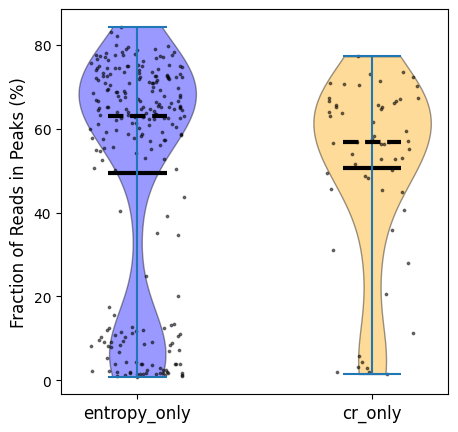

In [40]:
colors_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
gps = [ 'entropy_only', 'cr_only',]
x_positions = range(len(gps))
widths=0.5
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(5, 5))

# Violin plots

standard_peak_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'standard_peak_FRIP'] for c in gps]
entropy_values = [np.log10(entropy_df.loc[entropy_df['identified_by_atac'] == c, 'Entropy']) for c in gps]
color_range = (np.log10(entropy_df['Entropy'].min()), np.log10(entropy_df['Entropy'].max()))


vp1 = ax.violinplot( standard_peak_data, 
              positions=x_positions, widths=widths, vert=True, showmedians=True,
              showmeans=True)
add_label(vp1, 'In Standard Peaks')

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.5, s=3) # s controls point size



for i, group_data in enumerate(standard_peak_data):
    add_jittered_points(ax, group_data, x_positions[i], jitter_width=0.2, color='black')


for i, body in enumerate(vp1['bodies']):
    body.set_facecolor('blue' if gps[i]=='entropy_only' else 'orange')
    body.set_edgecolor('black')
    body.set_alpha(0.4)
vp1['cmedians'].set_color('black') 
vp1['cmedians'].set_linestyles('--')
vp1['cmedians'].set_linewidth(3)
vp1['cmeans'].set_linewidth(3)
vp1['cmeans'].set_color('black') 


ax.set_xticks(x_positions)
ax.set_xticklabels(gps, rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)

median_frip_standard_peak = [standard_peak_data[i].median() for i in range(len(gps))]
print("FRIP \t entropy_only \t cr_only \n")

[Text(0, 0, 'both'),
 Text(1, 0, 'entropy_only'),
 Text(2, 0, 'cr_only'),
 Text(3, 0, 'none')]

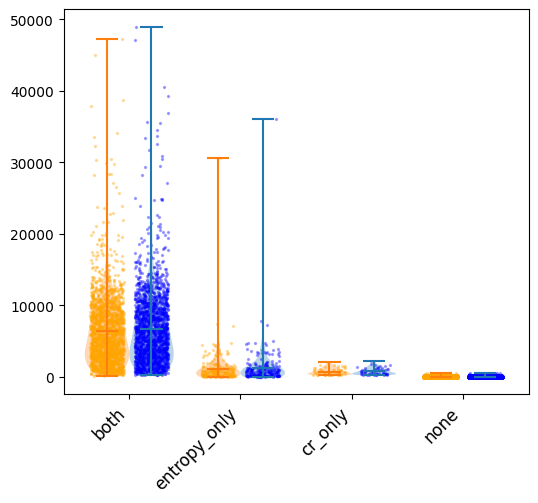

In [65]:
colors = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
gps = ['both', 'entropy_only', 'cr_only', 'none']
x_positions = range(len(gps))
widths=0.4
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(6, 5))

# Violin plots

standard_peak_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'Nfrag_overlap_standard_peak'] for c in gps]
entropy_peak_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'Nfrag_overlap_entropy_peak'] for c in gps]

add_label(ax.violinplot( entropy_peak_data, 
              positions=[x + 0.2 for x in x_positions], widths=widths, vert=True, 
              showmeans=True,), 'In Entropy Peaks')
add_label(ax.violinplot( standard_peak_data, 
              positions=[x - 0.2 for x in x_positions], widths=widths, vert=True, 
              showmeans=True), 'In Standard Peaks')

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.15, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size

for i, group_data in enumerate(standard_peak_data):
    add_jittered_points(ax, group_data, x_positions[i] - 0.2, color='orange')
for i, group_data in enumerate(entropy_peak_data):
    add_jittered_points(ax, group_data, [x + 0.2 for x in x_positions][i], color='blue')



ax.set_xticks(x_positions)
ax.set_xticklabels(gps, rotation=45, ha='right', fontsize=12)


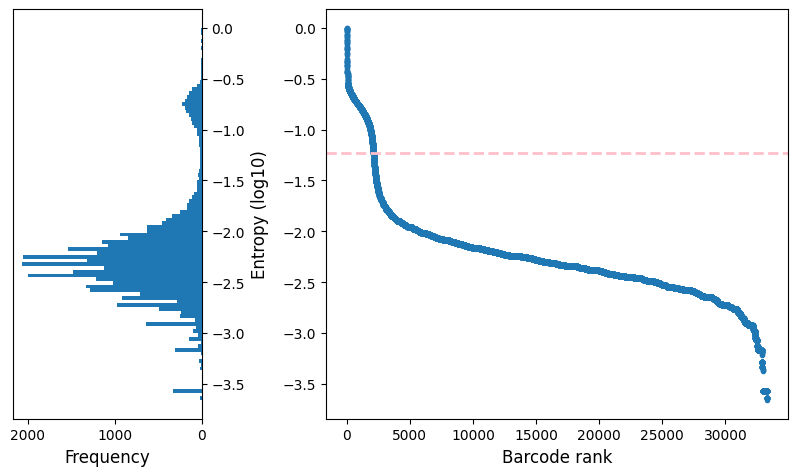

In [213]:
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(30, 20)

ax0 = fig.add_subplot(gs[0:20,0:5])
_ = ax0.hist(np.log10(entropy_df['Entropy']), orientation='horizontal', bins=100)
# move y-tick ro the right side 
ax0.yaxis.tick_right()
ax0.yaxis.set_label_position('right')
ax0.invert_xaxis()
ax0.set_ylabel('Entropy (log10)', fontsize=12)
ax0.set_xlabel('Frequency', fontsize=12)


ax1 = fig.add_subplot(gs[0:20,8:])

sorted_log10entropy_list = np.log10(entropy_df['Entropy'].dropna().sort_values(ascending=False).values)
rank_list = np.arange( len(sorted_log10entropy_list) )
entropy_cutoff = entropy_df.loc[entropy_df['atac_pass_entropy'], 'Entropy'].min()
entropy_cutoff_log = np.log10(entropy_cutoff)


ax1.plot( rank_list, sorted_log10entropy_list, 'o', markersize=3)
ax1.set_xlabel('Barcode rank', fontsize=12)
# ax1.set_ylabel('log(Entropy)', fontsize=12)
ax1.axhline(entropy_cutoff_log, color='pink', linestyle='--', label='entropy threshold', lw=2)


----- 	 both 	 entropy_only 	 cr_only 	 none
mean 	 [64.83361841785602, 49.474955830539315, 50.6086314955297, 5.420781219583986]
median 	 [67.05558858501783, 63.065230335425326, 56.78960603520537, 4.362416107382551]


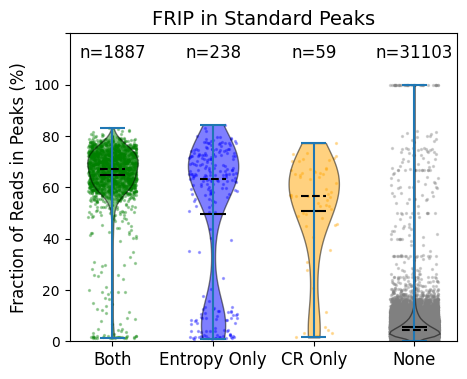

In [108]:
fig, ax = plt.subplots(figsize=(5, 4))

x_positions = range(4)
width = 0.5

colors = ['green', 'blue', 'orange', 'gray']
entropy_vales = [ entropy_df.loc[entropy_df['identified_by_atac'] == cat, 'standard_peak_FRIP'] for cat in ['both', 'entropy_only', 'cr_only', 'none'] ]
total_counts = [a.shape[0] for a in entropy_vales]

mean_entropy_values = [np.mean(a) for a in entropy_vales]
median_entropy_values = [np.median(a) for a in entropy_vales]

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(entropy_vales):
    add_jittered_points(ax, group_data, x_positions[i], color=colors[i])


v1 = ax.violinplot( entropy_vales, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Both', 'Entropy Only', 'CR Only', 'None'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 120)
ax.set_yticks(range(0, 121, 20))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

ax.set_title('FRIP in Standard Peaks', fontsize=14)

print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_entropy_values}')
print(f'median \t {median_entropy_values}')

----- 	 both 	 entropy_only 	 cr_only 	 none
mean 	 [67.30619038747956, 51.41261077847256, 52.11442739696759, 5.77335584249837]
median 	 [69.62162162162161, 66.03347714924897, 58.51318944844125, 4.69208211143695]


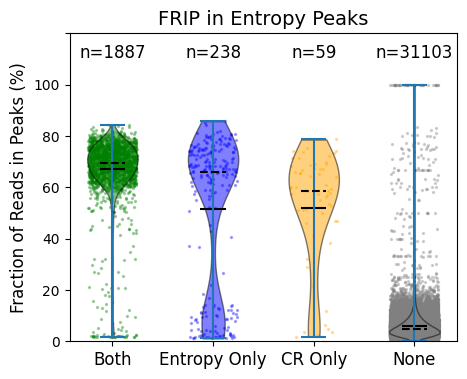

In [109]:
fig, ax = plt.subplots(figsize=(5, 4))

x_positions = range(4)
width = 0.5

colors = ['green', 'blue', 'orange', 'gray']
entropy_vales = [ entropy_df.loc[entropy_df['identified_by_atac'] == cat, 'entropy_peak_FRIP'] for cat in ['both', 'entropy_only', 'cr_only', 'none'] ]
total_counts = [a.shape[0] for a in entropy_vales]

mean_entropy_values = [np.mean(a) for a in entropy_vales]
median_entropy_values = [np.median(a) for a in entropy_vales]

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(entropy_vales):
    add_jittered_points(ax, group_data, x_positions[i], color=colors[i])


v1 = ax.violinplot( entropy_vales, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Both', 'Entropy Only', 'CR Only', 'None'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 120)
ax.set_yticks(range(0, 121, 20))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

ax.set_title('FRIP in Entropy Peaks', fontsize=14)

print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_entropy_values}')
print(f'median \t {median_entropy_values}')



----- 	 both 	 entropy_only 	 cr_only 	 none
mean 	 [2.47257196962355, 1.937654947933248, 1.5057959014378905, 0.3525746229143849]
median 	 [2.3693647540983562, 2.0777027027027017, 1.4025245441795278, 0.20491803278688536]


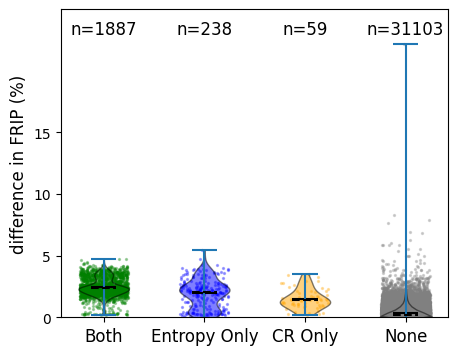

In [110]:
fig, ax = plt.subplots(figsize=(5, 4))

x_positions = range(4)
width = 0.5

colors = ['green', 'blue', 'orange', 'gray']
entropy_vales = [ entropy_df.loc[entropy_df['identified_by_atac'] == cat, 'entropy_peak_FRIP'] - \
    entropy_df.loc[entropy_df['identified_by_atac'] == cat, 'standard_peak_FRIP'] for \
        cat in ['both', 'entropy_only', 'cr_only', 'none'] ]
total_counts = [a.shape[0] for a in entropy_vales]

mean_entropy_values = [np.mean(a) for a in entropy_vales]
median_entropy_values = [np.median(a) for a in entropy_vales]

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(entropy_vales):
    add_jittered_points(ax, group_data, x_positions[i], color=colors[i])


v1 = ax.violinplot( entropy_vales, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Both', 'Entropy Only', 'CR Only', 'None'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('difference in FRIP (%)', fontsize=12)
ax.set_ylim(0, 25)
ax.set_yticks(range(0, 20, 5))


for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)
    
print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_entropy_values}')
print(f'median \t {median_entropy_values}')


In [111]:
if 'identified_by_atac' not in h5_rna.obs.columns:
    h5_rna.obs = h5_rna.obs.merge(entropy_df[['rna_barcodes', 'identified_by_atac', 'rna_pass_CR']],  left_index=True, right_on='rna_barcodes', how='left')

In [115]:
h5_rna.obs.groupby('identified_by_atac').size()

/tmp/ipykernel_3161974/2428117809.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna.obs.groupby('identified_by_atac').size()


identified_by_atac
both            1887
entropy_only     238
dtype: int64

<Axes: xlabel='leiden_RNA_scVI', ylabel='count'>

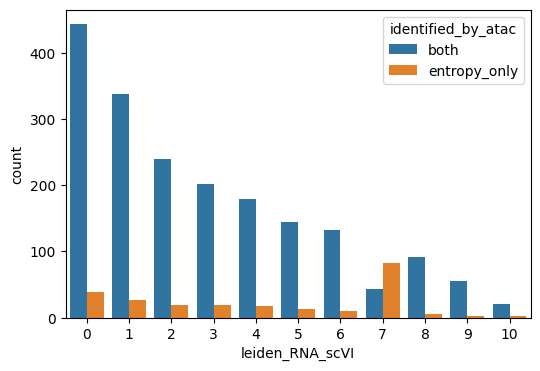

In [118]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=h5_rna.obs, x='leiden_RNA_scVI', hue='identified_by_atac', ax=ax)

In [229]:
if 'Entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop(columns=['Entropy'], inplace=True)
    
new_h5_rna_obs = h5_rna.obs.merge(entropy_df[['Entropy']], left_index=True, right_index=True, how='left')
if new_h5_rna_obs.index.name == 'atac_barcodes':
    h5_rna.obs = new_h5_rna_obs

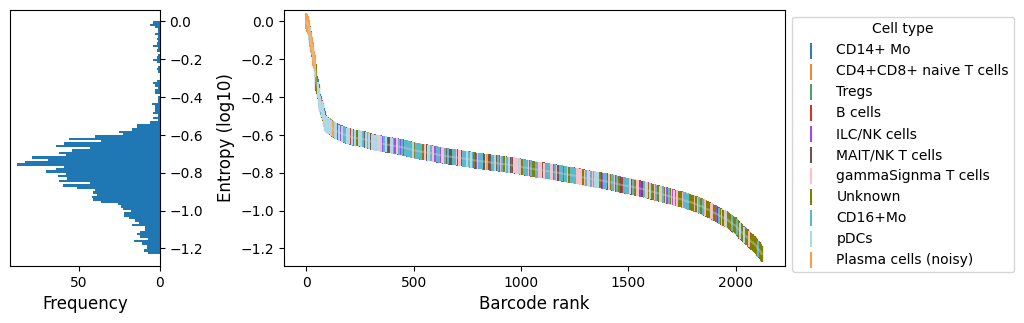

In [310]:
color_order = {'0': '#3d77af', '1': '#ed853b', '2': '#559a6f', '3': '#c53b34', '4': '#9d48f3',
             '5': '#6b524b', '6': 'pink', '7': 'olive', '8': '#5db7cb', '9': 'lightblue', 
                '10': '#f6a04d', '11': '#8fd18b', '12': 'lightcoral'}


fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(30, 20)

ax0 = fig.add_subplot(gs[0:20,0:4])
_ = ax0.hist(np.log10(h5_rna.obs['Entropy']), orientation='horizontal', bins=100)
# move y-tick ro the right side 
ax0.yaxis.tick_right()
ax0.yaxis.set_label_position('right')
ax0.invert_xaxis()
# ax0.set_ylabel('Entropy (log10)', fontsize=12)
ax0.set_xlabel('Frequency', fontsize=12)


ax1 = fig.add_subplot(gs[0:20,7:])


sorted_log10entropy_series = np.log10(h5_rna.obs['Entropy'].sort_values(ascending=False)).to_frame()  # with barcodes as index 
rank_list = np.arange( sorted_log10entropy_series.shape[0] )
sorted_log10entropy_series['rank_list'] = rank_list



ax1.plot( sorted_log10entropy_series['rank_list'], sorted_log10entropy_series['Entropy'], '-', markersize=1, color='lightgray', alpha=0.4)
ax1.set_xlabel('Barcode rank', fontsize=12)
ax1.set_ylabel('Entropy (log10)', fontsize=12)

for ct in [str(i) for i in np.arange(11)]:
    barcodes = h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == ct].index
    ax1.scatter(sorted_log10entropy_series.loc[barcodes, 'rank_list'], 
             sorted_log10entropy_series.loc[barcodes, 'Entropy'], color=color_order[ct], label=RNAcluster_celltype_map[ct], s=130, alpha=1, marker="|")
    
    ax1.legend(title='Cell type', bbox_to_anchor=(1, 1), loc='upper left')


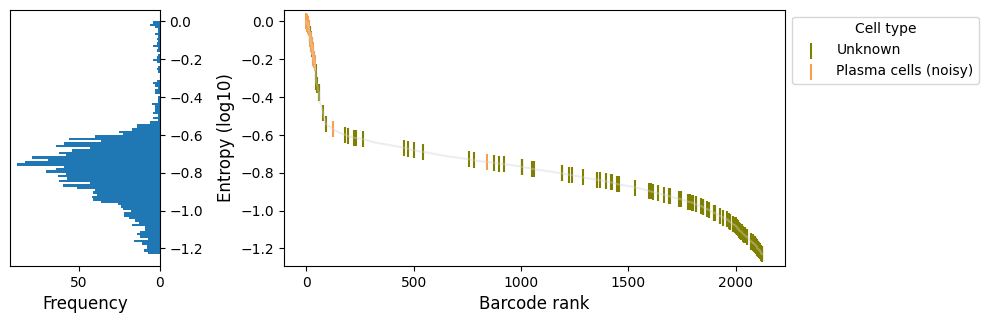

In [311]:
color_order = {'0': '#3d77af', '1': '#ed853b', '2': '#559a6f', '3': '#c53b34', '4': '#9d48f3',
             '5': '#6b524b', '6': 'pink', '7': 'olive', '8': '#5db7cb', '9': 'lightblue', 
                '10': '#f6a04d', '11': '#8fd18b', '12': 'lightcoral'}


fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(30, 20)

ax0 = fig.add_subplot(gs[0:20,0:4])
_ = ax0.hist(np.log10(h5_rna.obs['Entropy']), orientation='horizontal', bins=100)
# move y-tick ro the right side 
ax0.yaxis.tick_right()
ax0.yaxis.set_label_position('right')
ax0.invert_xaxis()
# ax0.set_ylabel('Entropy (log10)', fontsize=12)
ax0.set_xlabel('Frequency', fontsize=12)


ax1 = fig.add_subplot(gs[0:20,7:])


sorted_log10entropy_series = np.log10(h5_rna.obs['Entropy'].sort_values(ascending=False)).to_frame()  # with barcodes as index 
rank_list = np.arange( sorted_log10entropy_series.shape[0] )
sorted_log10entropy_series['rank_list'] = rank_list



ax1.plot( sorted_log10entropy_series['rank_list'], sorted_log10entropy_series['Entropy'], '-', markersize=1, color='lightgray', alpha=0.4)
ax1.set_xlabel('Barcode rank', fontsize=12)
ax1.set_ylabel('Entropy (log10)', fontsize=12)

for ct in [str(i) for i in [7, 10]]:
    barcodes = h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == ct].index
    ax1.scatter(sorted_log10entropy_series.loc[barcodes, 'rank_list'], 
             sorted_log10entropy_series.loc[barcodes, 'Entropy'], color=color_order[ct], label=RNAcluster_celltype_map[ct], s=130, alpha=1, marker="|")
    
    ax1.legend(title='Cell type', bbox_to_anchor=(1, 1), loc='upper left')
